In [166]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import stats
import seaborn as sn
import pandas as pd
from sklearn.metrics import confusion_matrix

In [76]:
sn.set_theme(context="paper", style="whitegrid", font='sans-serif', color_codes=True, rc=None)


In [167]:
LABELS = ["SPH_9", "BH_n4_M8", "BH_n2_M10", "BH_n4_M10", "BH_n6_M10", "BH_n4_M12"]
CLASSES = len(LABELS)
LOAD_FOLDER = "../results/predictions/resnet"
MODEL_NAME = "thesis_ensemble"
LOAD_PATH = f"{LOAD_FOLDER}/{MODEL_NAME}.csv"
df = pd.read_csv(LOAD_PATH)
datasets = [0]*CLASSES
for i in range(CLASSES):
    df_temp = df[df["Truth"] == i ]
    datasets[i] = df_temp

#Calculate expected frequencies
cf_matrix = confusion_matrix(df["Truth"].astype(int), df["Prediction"].astype(int), normalize="true")
expected_frequencies = np.array([row[i] for i, row in enumerate(cf_matrix)])

In [77]:
def binomial_probability(k, n, nu):
    if k > n:
        print("k is larger than n!!")
        print(n, k)
    coeff = (math.factorial(n))/(math.factorial(k)*math.factorial(n-k))
    return coeff*(nu**k)*(1-nu)**(n-k)

In [78]:
def poisson_probability(k, n, nu):
    if k > n:
        print("k is larger than n!!")
        print(n, k)
    lambda_val = nu*n
    return lambda_val**k*np.exp(-lambda_val)/math.factorial(k)

In [184]:
def p_value(k, n, nu_exp, stat="binomial"):
    p = 0
    for i in range(0, k+1):
        if stat=="binomial":
            p = p + binomial_probability(i, n, nu_exp)
        elif stat=="poisson":
            p = p + poisson_probability(i, n, nu_exp)
        else:
            return None
    return p

def weighted_percentile(values, weights, percentile_lower, percentile_upper):
    # Only works for convex distribution
    df = pd.DataFrame({"values":values, "weights":weights})
    df = df.sort_values(by="values")
    percentile_added = 0
    lower_limit_found = False
    upper_limit_found = False
    lower_limit = df["values"].min()
    upper_limit = df["values"].max()
    for i in range(len(df)):
        #Keep lower limit BELOW
        if lower_limit_found == False:
            lower_limit = df["values"][i]
        percentile_added = percentile_added + df["weights"][i]*100
        if (percentile_added >= percentile_lower) and (lower_limit_found == False):
            lower_limit_found = True
            #print("Actual lower limit percentile: ", percentile_added)
        #And upper ABOVE
        if (percentile_added >= percentile_upper) and (upper_limit_found == False):
            upper_limit = df["values"][i]
            upper_limit_found = True
            #print("Actual upper limit percentile: ", percentile_added)
        if upper_limit_found:
            return lower_limit, upper_limit
    return lower_limit, upper_limit


[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]


Text(0, 0.5, 'Probability')

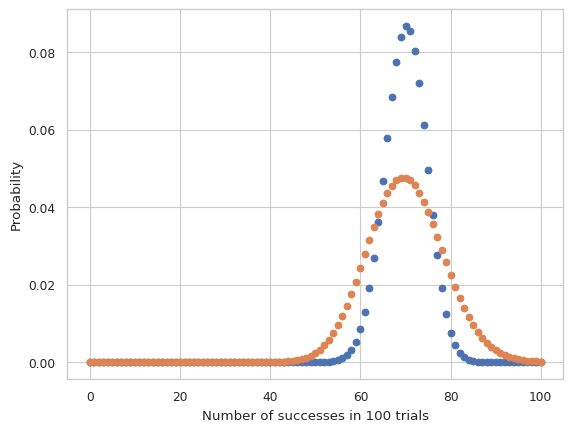

In [80]:
N = 100
nu = 0.7
k_list = np.arange(0, N+1)
print(k_list)
probs_binomial = [binomial_probability(k, N, nu) for k in k_list]
probs_poisson = [poisson_probability(k, N, nu) for k in k_list]
plt.scatter(k_list, probs_binomial)
plt.scatter(k_list, probs_poisson)
plt.xlabel(f"Number of successes in {N} trials")
plt.ylabel("Probability")

## Expected value unbiased estimator

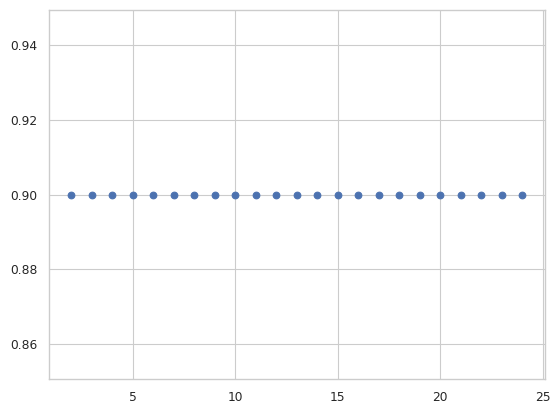

In [81]:
def expected_frequency(n, nu):
    k_list = np.arange(0, n+1)
    expected_value = 0
    for k in k_list:
        frequency = k/n
        prob = binomial_probability(k, n, nu)
        expected_value = expected_value + prob*frequency
    return expected_value

n_list = np.arange(2, 25)
nu=0.9
exp_values = [expected_frequency(n, nu) for n in n_list]
plt.scatter(n_list, exp_values)

Text(0, 0.5, 'Possible frequencies')

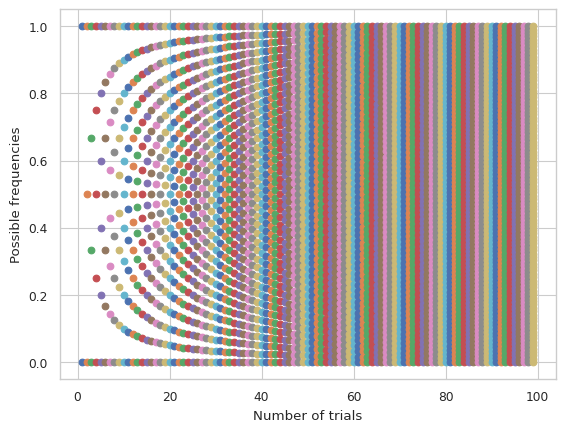

In [82]:
n_list = np.arange(1, 100)
frequencies = [[0]*(n) for n in n_list]
probabilites = [[0]*(n) for n in n_list]
nu=0.3

for i, n in enumerate(n_list):
    k_list = np.arange(0, n+1)
    frequencies[i] = [k/n for k in k_list]
    probabilites[i] = [binomial_probability(k, n, nu) for k in k_list]

fig, ax = plt.subplots()
for i in range(len(n_list)):
    f_values = frequencies[i]
    ax.scatter([n_list[i]]*len(f_values), f_values)
ax.set_xlabel("Number of trials")
ax.set_ylabel("Possible frequencies")

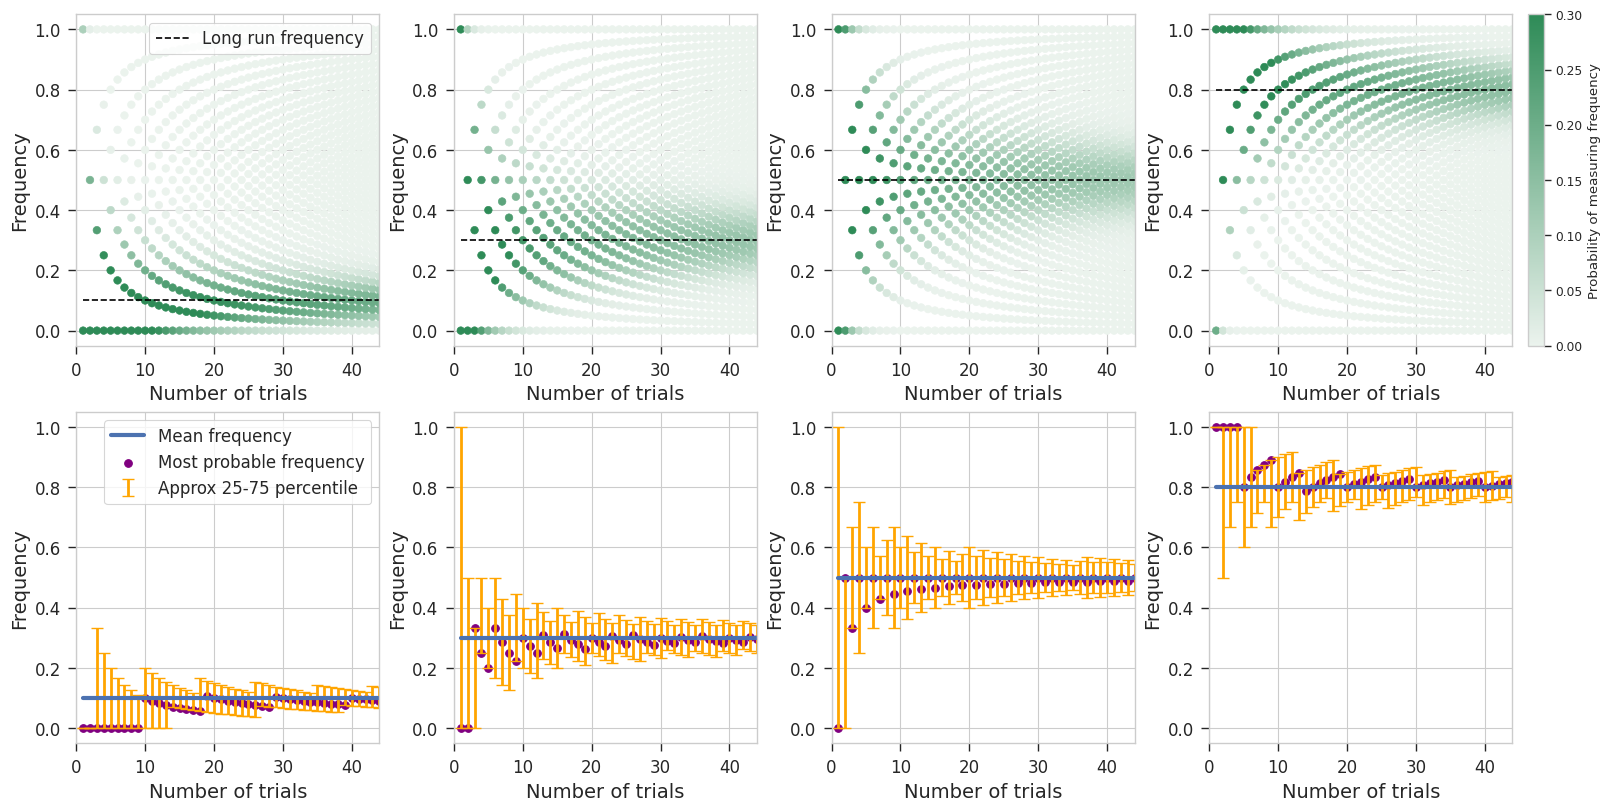

In [140]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16,8), layout="constrained")

n_list = np.arange(1, 45)
nu_vals = [0.1, 0.3, 0.5, 0.8]

for i, nu in enumerate(nu_vals):
    mean_vals = np.zeros(len(n_list))
    most_prob_vals = np.zeros(len(n_list))
    err_up = np.zeros(len(n_list))
    err_down = np.zeros(len(n_list))
    norm = plt.Normalize(0, 0.3)
    sm = plt.cm.ScalarMappable(cmap=sn.light_palette("seagreen", as_cmap=True), norm=norm)
    for j in range(len(n_list)):
        n = n_list[j]
        k_list = np.arange(0, n+1)
        f_values = np.array([k/n for k in k_list])
        probs = np.array([binomial_probability(k, n, nu) for k in k_list])
        sn.scatterplot(x=[n_list[j]]*len(f_values), y=f_values, hue=probs, s=30, legend=False, ax=axs[0][i], palette=sn.light_palette("seagreen", as_cmap=True), hue_norm=norm, edgecolor='face')
        mean_vals[j] = np.array(f_values*probs).sum()
        most_prob_vals[j] = f_values[probs.argmax()]
        err_down[j], err_up[j] = weighted_percentile(f_values, probs, 25, 75)
    axs[0][i].plot([n_list[0], n_list[-1]], [nu, nu], color="black", linestyle="--", label="Long run frequency")
    
    #axs[1][i].scatter(n_list, err_down, label="Approx 25 percentile", color="red", s=10, alpha=0.5, edgecolor="face")
    #axs[1][i].scatter(n_list, err_up, label="Approx 75 percentile", color="blue", s=10, alpha=0.5, edgecolor="face")
    axs[1][i].errorbar(n_list, err_down, yerr=(np.zeros(len(err_down)), np.abs(err_up-err_down)), capsize=4, elinewidth=2, color="orange", label="Approx 25-75 percentile", fmt='none')
    axs[1][i].plot(n_list, mean_vals, linewidth=3, label="Mean frequency")
    axs[1][i].scatter(n_list, most_prob_vals, s=30, label="Most probable frequency", color="purple")


axs[0][3].figure.colorbar(sm, ax=axs[0][3], label="Probability of measuring frequency")
axs[0][0].legend(loc="upper right", fontsize=12)
axs[1][0].legend(loc="upper right", fontsize=12)
for ax in axs.flatten():
    ax.set_xlabel("Number of trials", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.set_ylim(-0.05,1.05)
    ax.set_xlim(n_list[0]-1, n_list[-1])
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)


array([0.        , 0.        , 0.33333333, 0.25      , 0.2       ,
       0.16666667, 0.14285714, 0.125     , 0.11111111, 0.2       ,
       0.18181818, 0.16666667, 0.15384615, 0.07142857, 0.06666667,
       0.0625    , 0.05882353, 0.11111111, 0.10526316, 0.1       ,
       0.0952381 , 0.09090909, 0.08695652, 0.08333333, 0.08      ,
       0.11538462, 0.07407407, 0.07142857, 0.06896552, 0.06666667,
       0.06451613, 0.0625    , 0.06060606, 0.05882353, 0.08571429,
       0.08333333, 0.08108108, 0.07894737, 0.05128205, 0.05      ,
       0.04878049, 0.04761905, 0.06976744, 0.06818182])

Text(0, 0.5, 'Possible p-values')

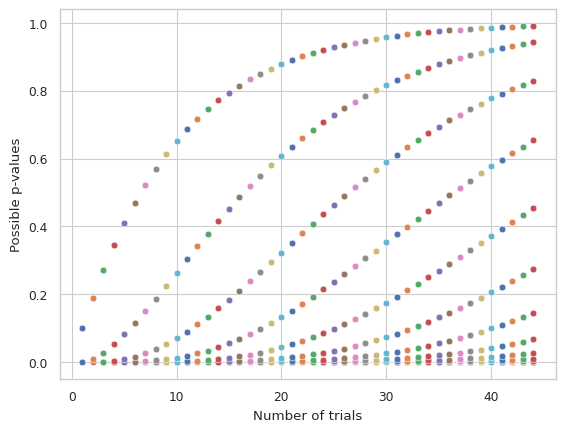

In [141]:
def p_value(k, n, nu_exp):
    p = 0
    for i in range(0, k):
        p = p + binomial_probability(i, n, nu_exp)
    return p
fig, ax = plt.subplots()
nu_exp=0.9
nu_true=0.7
p_values = [[0]*(n) for n in n_list]
for i in range(len(n_list)):
    n=n_list[i]
    k_list = np.arange(0, n+1)
    p_values[i] = [p_value(k, n, nu_exp) for k in k_list]
    sn.scatterplot(x=[n_list[i]]*len(p_values[i]), y=p_values[i], legend=False, ax=ax)
ax.set_xlabel("Number of trials")
ax.set_ylabel("Possible p-values")

In [175]:
cf_matrix[:,1]

array([0.03886667, 0.77173333, 0.08166667, 0.09673333, 0.11213333,
       0.00966667])

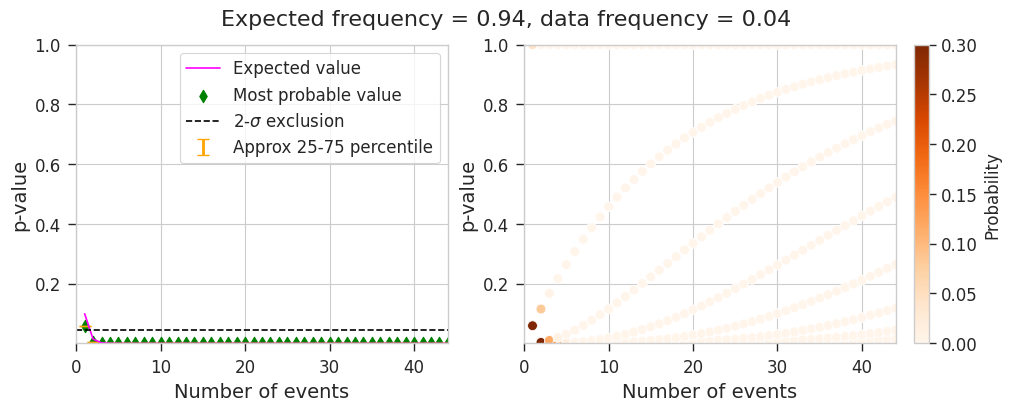

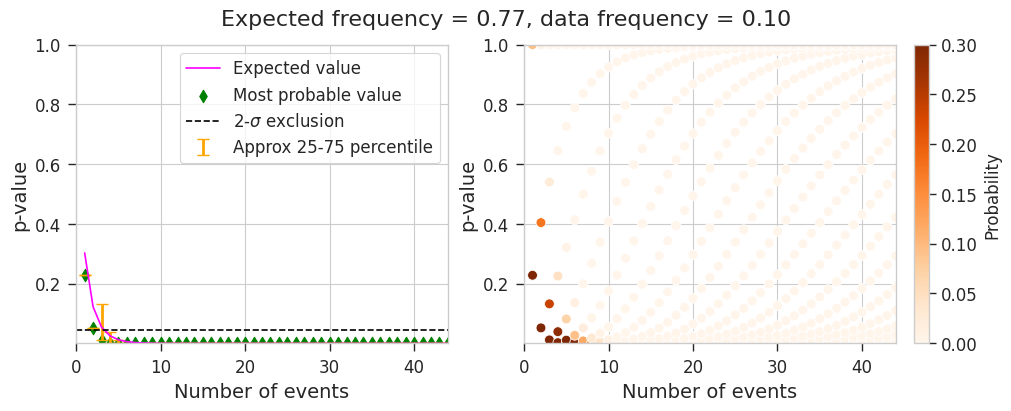

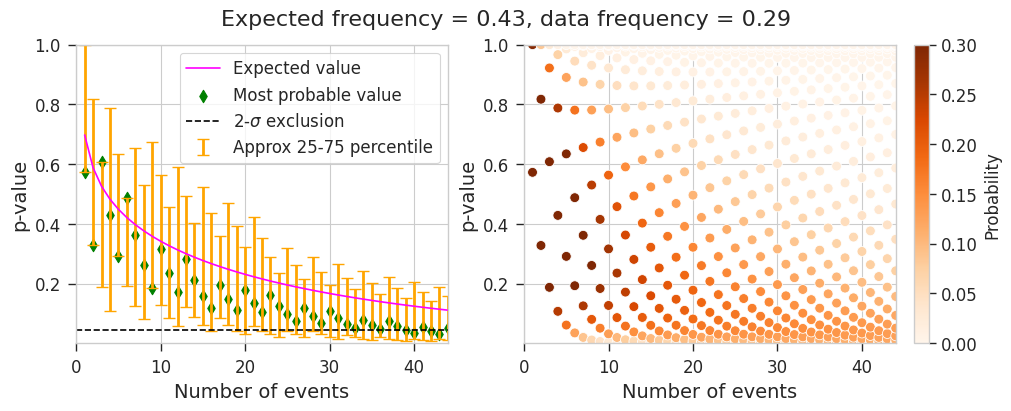

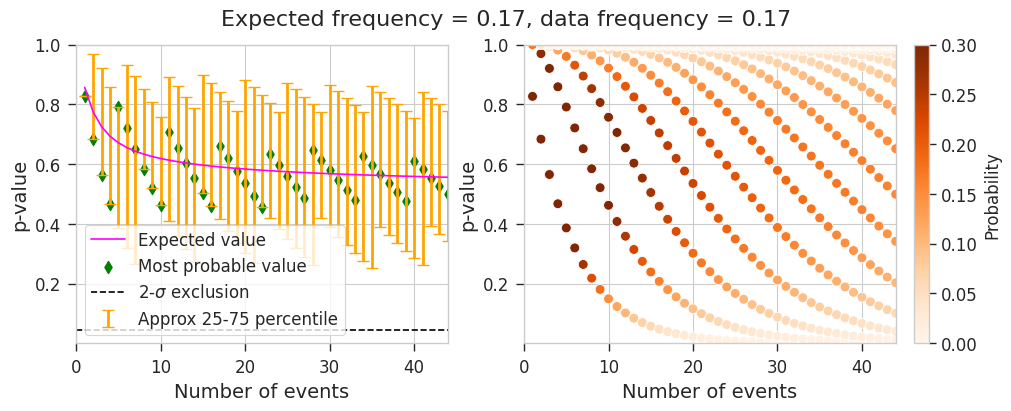

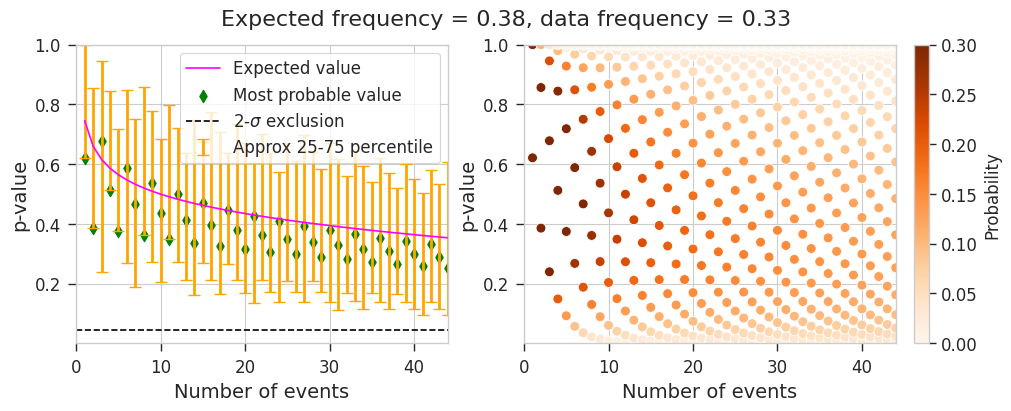

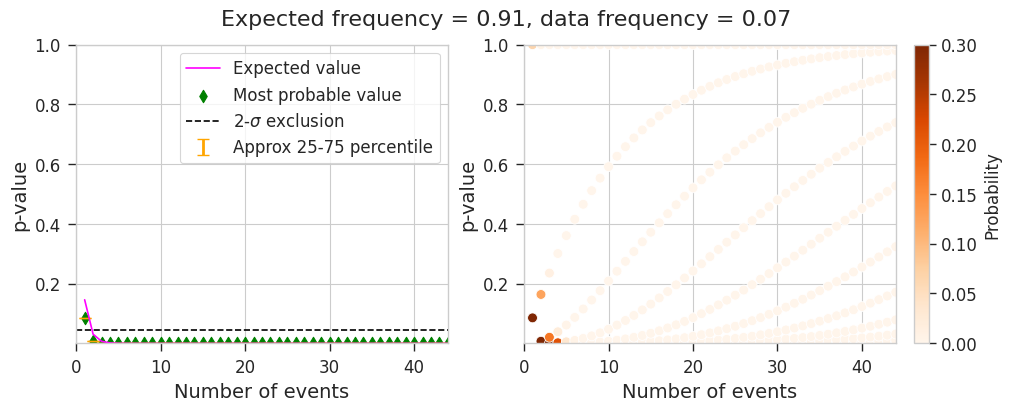

In [195]:

norm = plt.Normalize(0, 0.3)
sm = plt.cm.ScalarMappable(cmap="Oranges", norm=norm)
n_list = np.arange(1, 45)
data=3
nu_exp_list=expected_frequencies
nu_true_list=cf_matrix[data]
#[0.9, 0.7, 0.5, 0.3]

for j in range(len(nu_exp_list)):
    fig, axs = plt.subplots(ncols=2, figsize=(10,4), layout="constrained")
    nu_exp = nu_exp_list[j]
    nu_true = nu_true_list[j]
    fig.suptitle(f"Expected frequency = {nu_exp:.2f}, data frequency = {nu_true:.2f}", fontsize=16)
    p_values = [[0]*(n) for n in n_list]
    mean_vals = np.zeros(len(n_list))
    most_prob_vals = np.zeros(len(n_list))
    err_up = np.zeros(len(n_list))
    err_down = np.zeros(len(n_list))

    for i in range(len(n_list)):
        n=n_list[i]
        k_list = np.arange(0, n+1)
        #The actual probabilities
        probs = np.array([binomial_probability(k, n, nu_true) for k in k_list])
        #p values of the theory we are testing
        p_values[i] = np.array([p_value(k, n, nu_exp, stat="binomial") for k in k_list])
        sn.scatterplot(x=[n_list[i]]*len(p_values[i]), y=p_values[i], s=50, hue=probs, hue_norm=norm, legend=False, ax=axs[1], palette="Oranges")
        mean_vals[i] = np.array(p_values[i]*probs).sum()
        most_prob_vals[i] = p_values[i][probs.argmax()]
        err_down[i], err_up[i] = weighted_percentile(p_values[i], probs, 25, 75)

    #axs[0].scatter(n_list, err_down, label="Approx 25 percentile", color="red", s=50, alpha=0.5)
    #axs[0].scatter(n_list, err_up, label="Approx 75 percentile", color="blue", s=50, alpha=0.5)
    axs[0].errorbar(n_list, err_down, yerr=(np.zeros(len(err_down)), np.abs(err_up-err_down)), capsize=4, elinewidth=2, color="orange", label="Approx 25-75 percentile", fmt='none')
    axs[0].plot(n_list, mean_vals, label="Expected value", color="magenta")
    axs[0].scatter(n_list, most_prob_vals, s=40, marker="d", label="Most probable value", color="green")
    axs[0].plot([0,45], [0.0455, 0.0455], linestyle="--", label=r"2-$\sigma$ exclusion", color="black")


    #axs[1].figure.colorbar(sm, ax=axs[1], label="Probability")
    cbar = axs[1].figure.colorbar(sm, ax=axs[1])
    cbar.set_label(label="Probability", size=12)
    cbar.ax.tick_params(labelsize=12)

    for ax in axs.flatten():
        ax.set_xlabel("Number of events", fontsize=14)
        ax.set_ylabel("p-value", fontsize=14)
        #ax.set_yscale("log")
        ax.set_ylim(10**(-3), 1)
        ax.set_xlim(n_list[0]-1, n_list[-1])
        ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)

    axs[0].legend(fontsize=12)

TypeError: percentile() got an unexpected keyword argument 'weights'

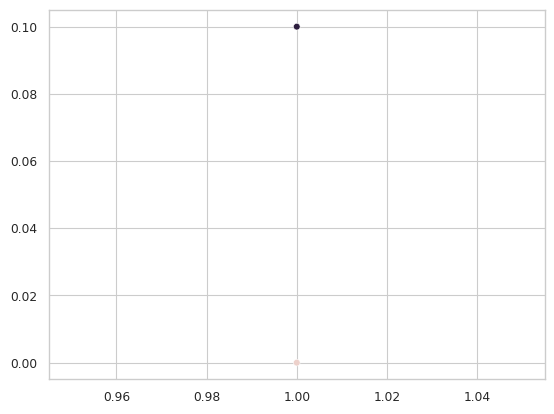

In [86]:
def p_value(k, n, nu_exp):
    p = 0
    for i in range(0, k):
        p = p + binomial_probability(i, n, nu_exp)
    return p
fig, ax = plt.subplots()
nu_exp=0.9
nu_true=0.9
p_values = [[0]*(n) for n in n_list]
mean_vals = np.zeros(len(n_list))
most_prob_vals = np.zeros(len(n_list))
err_up = np.zeros(len(n_list))
err_down = np.zeros(len(n_list))
for i in range(len(n_list)):
    n=n_list[i]
    k_list = np.arange(0, n+1)
    probs = np.array([binomial_probability(k, n, nu_true) for k in k_list])
    p_values[i] = [p_value(k, n, nu_exp) for k in k_list]
    sn.scatterplot(x=[n_list[i]]*len(p_values[i]), y=p_values[i], hue=probs, legend=False, ax=ax)
    mean_vals[i] = np.array(p_values[i]*probs).sum()
    most_prob_vals[i] = p_values[i][probs.argmax()]
    err_up = np.percentile(p_values[i], 95, weights=probs)
    err_down = np.percentile(p_values[i], 5, weights=probs)
        

ax.plot(n_list, mean_vals, label="Mean")
ax.plot(n_list, most_prob_vals, label="Mode")
ax.set_xlabel("Number of trials")
ax.set_ylabel("Possible p-values")
ax.set_yscale("log")
ax.set_ylim(10**(-5),1)
ax.legend(loc='lower right')


## Experiment

Text(0, 0.5, 'Measured frequencies')

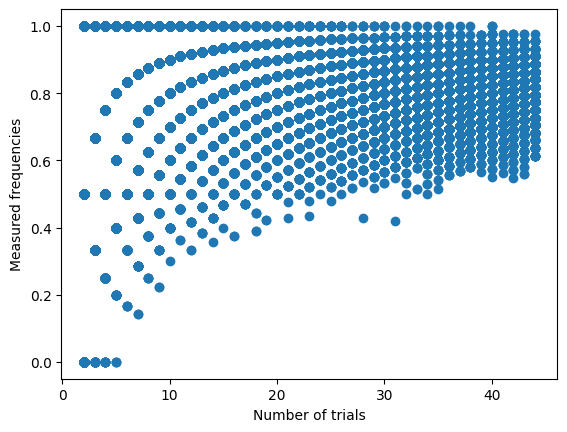

In [ ]:
fig, ax = plt.subplots()
n_list = np.arange(2, 45)
nu=0.8
M=3000
frequencies = np.zeros((M, len(n_list)))
for m in range(0,M):
    k_list = [np.random.binomial(n, nu) for n in n_list]
    frequencies[m] = [k_list[i]/n_list[i] for i in range(len(n_list))]
f_mean = frequencies.mean(axis=0)
err_up = np.percentile(frequencies, 95, axis=0)
err_down = np.percentile(frequencies, 35, axis=0)

ax.scatter([n_list]*M, frequencies, alpha=1)
#plt.errorbar(n_list, f_mean, yerr=(err_down, err_up))
ax.set_xlabel("Number of trials")
ax.set_ylabel("Measured frequencies")


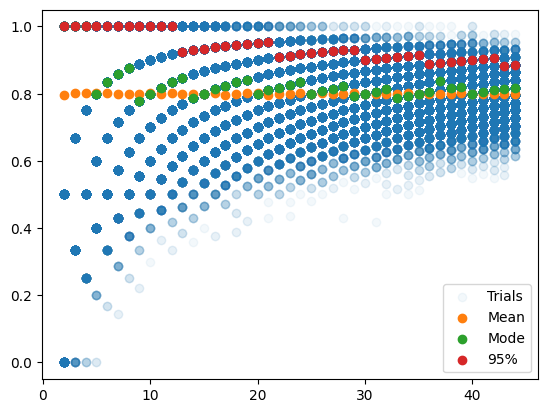

In [ ]:
fig, ax = plt.subplots()
ax.scatter([n_list]*M, frequencies, alpha=0.05, label="Trials")
ax.scatter(n_list, f_mean, label="Mean")
ax.scatter(n_list, stats.mode(frequencies, axis=0)[0], label="Mode")
ax.scatter(n_list, err_up, label="95%")
ax.legend()

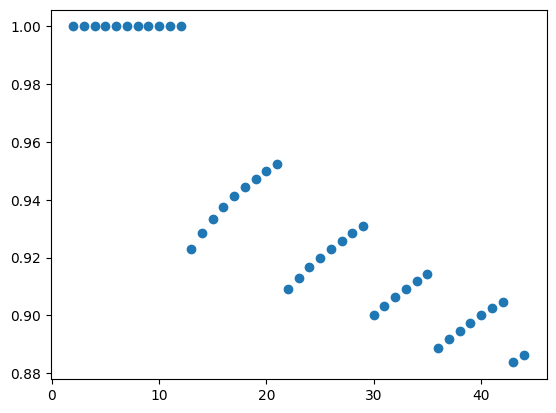

In [ ]:
plt.scatter(n_list, err_up)

In [ ]:
n_list = np.arange(2, 25)
nu_exp=0.9
nu_true=0.36
M = 1000
p_values = np.zeros((M, len(n_list)))

for m in range(0,M):
    k_list = [np.random.binomial(n, nu_true) for n in n_list]
    p_values[m] = [p_value(k_list[i], n_list[i], nu_exp) for i in range(len(n_list))]
    mean = p_values[m].mean()
p_mean = p_values.mean(axis=0)
err_up = np.percentile(p_values, 65, axis=0)
err_down = np.percentile(p_values, 35, axis=0)

plt.errorbar(n_list, p_mean, yerr=(err_down, err_up))
plt.yscale("log")

[0.18782756 0.17537338 0.1639329  0.15326202 0.1433265  0.13405156
 0.12538906 0.11729722 0.10973764 0.10267478 0.09607549 0.08990887
 0.08414606 0.07876016 0.07372604 0.0690203  0.06462108 0.060508
 0.05666208 0.0530656  0.04970203 0.04655597 0.04361306 0.0408599
 0.03828399 0.03587368 0.03361809 0.03150708 0.02953118 0.02768157
 0.02595    0.02432878 0.02281073 0.02138915 0.02005778 0.01881078
 0.0176427  0.01654843 0.01552323 0.01456264 0.01366251 0.01281897
 0.01202838]


(0.001, 1)

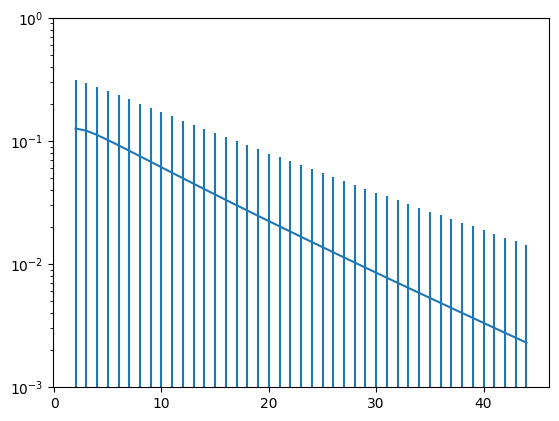

In [ ]:
def expected_p_value(n, nu_true, nu_expected):
    exp_value = 0
    variance = 0
    for k in range(0, n+1):
        prob = binomial_probability(k, n, nu_true)
        p = p_value(k, n, nu_expected)
        exp_value = exp_value + prob*p
    for k in range(0, n+1):
        prob = binomial_probability(k, n, nu_true)
        p = p_value(k, n, nu_expected)
        variance = variance + prob*(exp_value-p)**2
    return exp_value, variance

n_list = np.arange(2, 45)
nu_exp=0.49
nu_true = 0.22
p_values = np.zeros(len(n_list))
variances = np.zeros(len(n_list))

for i, n in enumerate(n_list):
    p_values[i], variances[i] = expected_p_value(n, nu_true, nu_exp)
print(np.sqrt(variances))
plt.errorbar(n_list, p_values, yerr=np.sqrt(variances))
plt.yscale("log")
plt.ylim(10**(-3), 1)